## Chuẩn bị 2 tập dữ liệu thô raw_data_train và raw_data_test và merge dữ liệu thành file raw-data

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


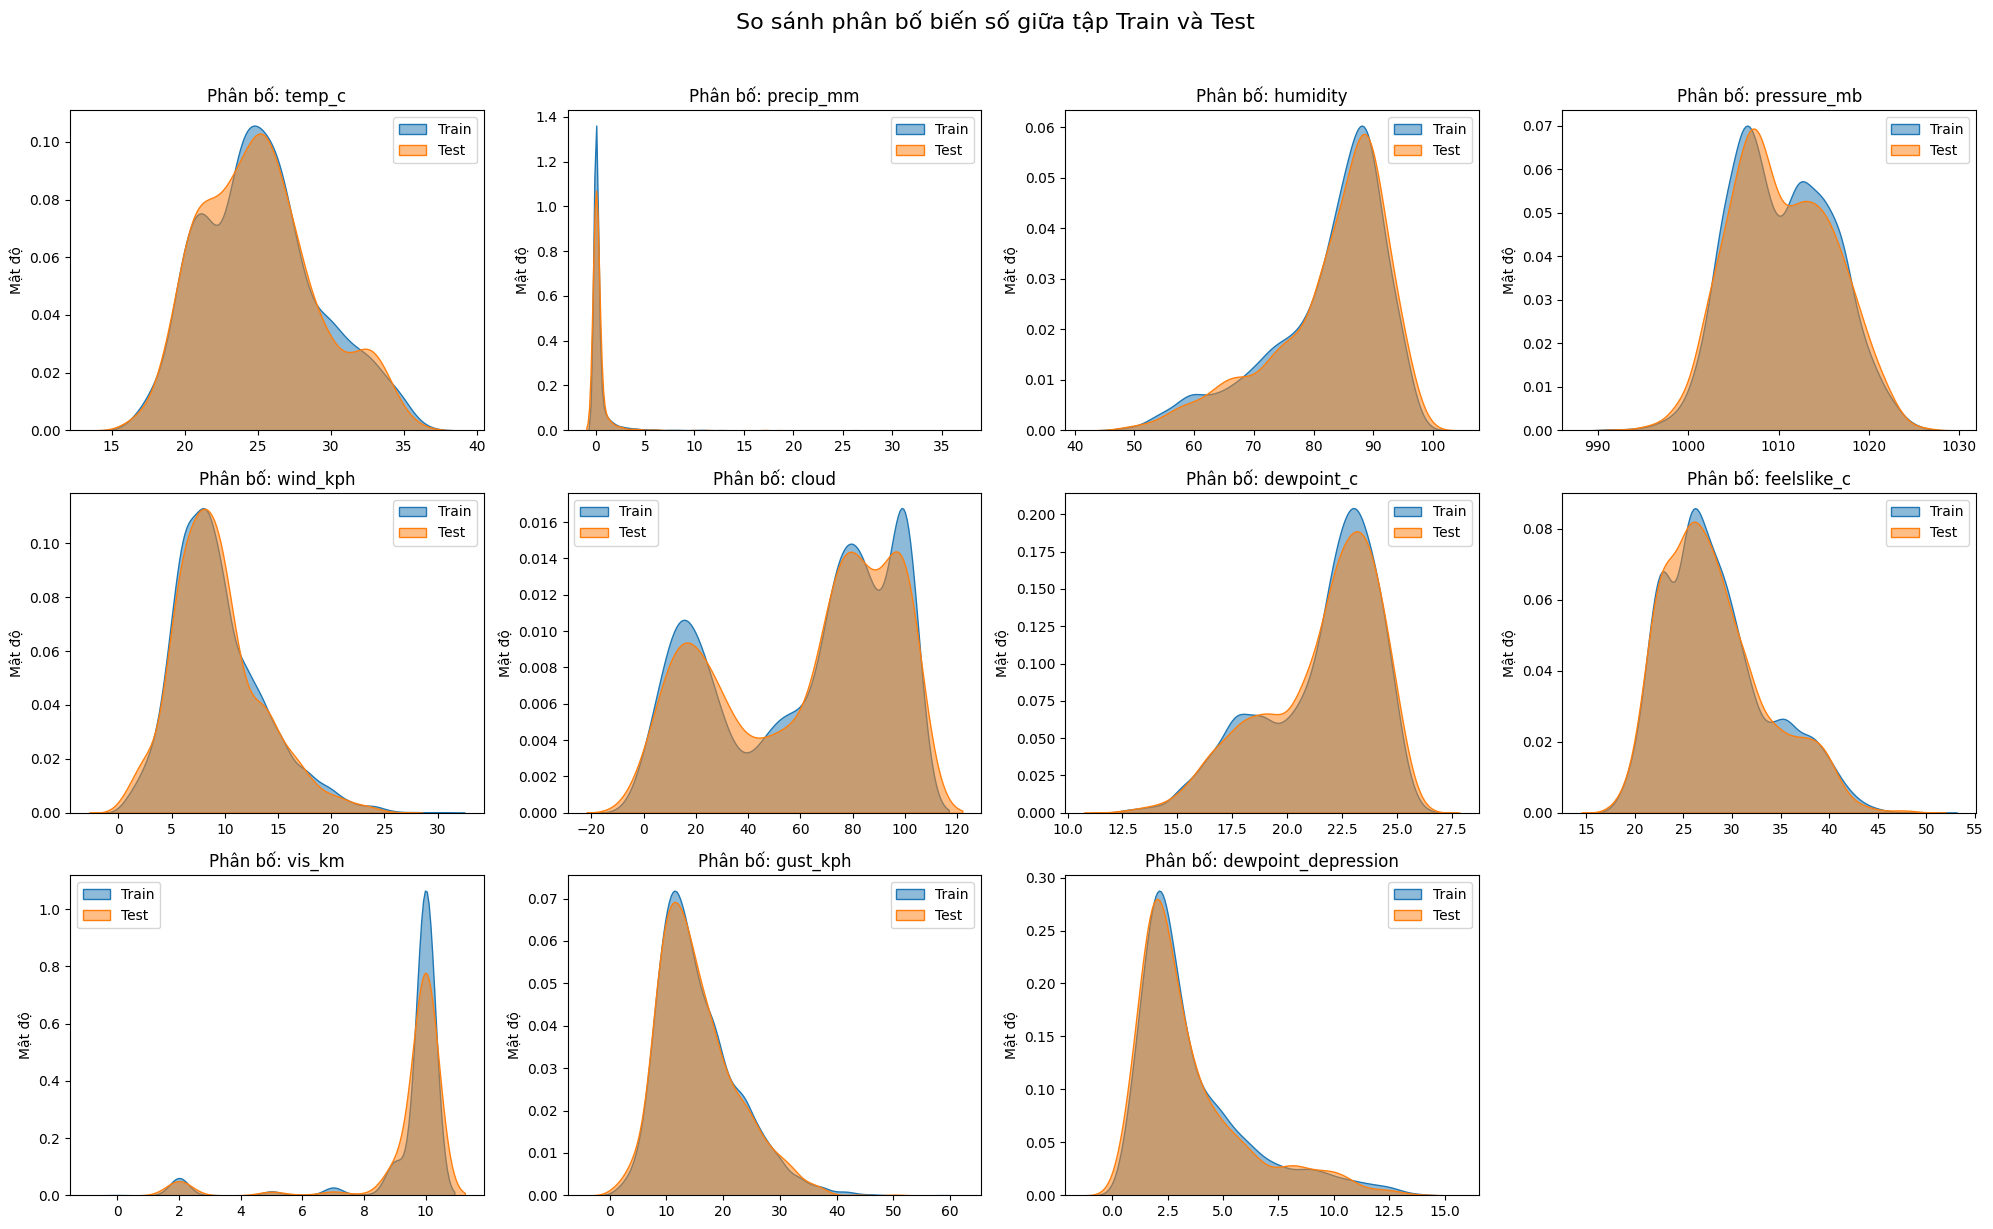

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

raw_data_train_df = pd.read_csv('/content/drive/MyDrive/Data_Science/raw_data_train.csv')
raw_data_test_df = pd.read_csv('/content/drive/MyDrive/Data_Science/raw_data_test.csv')

raw_data_train_df['source'] = 'Train'
raw_data_test_df['source'] = 'Test'

df = pd.concat([raw_data_train_df, raw_data_test_df], ignore_index=True)
df.to_csv('/content/drive/MyDrive/Data_Science/raw_data.csv', index=False)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

exclude_cols = ['time', 'wind_dir', 'condition']
numeric_cols = [col for col in numeric_cols if col not in exclude_cols]

n_cols = 4
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    sns.kdeplot(data=df[df['source'] == 'Train'], x=col, label='Train', fill=True, common_norm=False, alpha=0.5, ax=ax)
    sns.kdeplot(data=df[df['source'] == 'Test'], x=col, label='Test', fill=True, common_norm=False, alpha=0.5, ax=ax)
    ax.set_title(f'Phân bố: {col}')
    ax.set_xlabel('')
    ax.set_ylabel('Mật độ')
    ax.legend()

for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('So sánh phân bố biến số giữa tập Train và Test', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


## Tổng quan tập dữ liệu

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   time                 8760 non-null   object 
 1   temp_c               8760 non-null   float64
 2   precip_mm            8760 non-null   float64
 3   humidity             8760 non-null   int64  
 4   pressure_mb          8760 non-null   float64
 5   wind_kph             8760 non-null   float64
 6   cloud                8760 non-null   int64  
 7   dewpoint_c           8760 non-null   float64
 8   feelslike_c          8760 non-null   float64
 9   vis_km               8760 non-null   float64
 10  gust_kph             8760 non-null   float64
 11  wind_dir             8760 non-null   object 
 12  condition            8760 non-null   object 
 13  dewpoint_depression  8760 non-null   float64
 14  source               8760 non-null   object 
dtypes: float64(9), int64(2), object(4)
mem

In [4]:
df.head()

,time,temp_c,precip_mm,humidity,pressure_mb,wind_kph,cloud,dewpoint_c,feelslike_c,vis_km,gust_kph,wind_dir,condition,dewpoint_depression,source
0,2025-05-08 15:00,32.2,0.0,70,1003.0,12.1,14,25.0,40.6,10.0,19.3,E,Sunny,7.2,Train
1,2024-12-19 09:00,21.6,0.2,85,1020.0,14.7,100,18.9,23.6,9.0,25.4,NE,Patchy rain possible,2.7,Train
2,2025-05-07 19:00,28.9,0.0,91,1006.0,10.3,79,24.1,37.0,9.0,19.3,SSW,Cloudy,4.8,Train
3,2024-07-25 23:00,28.2,0.0,67,999.0,11.0,40,21.6,30.9,10.0,19.6,SW,Partly cloudy,6.6,Train
4,2025-01-07 22:00,19.9,0.3,84,1016.0,3.6,71,17.2,21.9,10.0,5.9,SSW,Patchy rain possible,2.7,Train


## Kiểm tra, làm sạch, xử lý ngoại lai, label encoder và trực quan hóa tập dữ liệu

In [5]:
print("\nSố điểm dữ liệu NaN:")
print(df.isna().sum())


Số điểm dữ liệu NaN:
time                   0
temp_c                 0
precip_mm              0
humidity               0
pressure_mb            0
wind_kph               0
cloud                  0
dewpoint_c             0
feelslike_c            0
vis_km                 0
gust_kph               0
wind_dir               0
condition              0
dewpoint_depression    0
source                 0
dtype: int64


In [6]:
df.drop(columns=['wind_dir'], inplace=True)

df['time'] = pd.to_datetime(df['time'])

df['hour'] = df['time'].dt.hour

df.drop(columns=['time'], inplace=True)

In [7]:
num_cols = ["humidity", "wind_kph", "cloud", "dewpoint_c", "feelslike_c",'gust_kph','dewpoint_depression']

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7536 entries, 1 to 8759
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   temp_c               7536 non-null   float64
 1   precip_mm            7536 non-null   float64
 2   humidity             7536 non-null   int64  
 3   pressure_mb          7536 non-null   float64
 4   wind_kph             7536 non-null   float64
 5   cloud                7536 non-null   int64  
 6   dewpoint_c           7536 non-null   float64
 7   feelslike_c          7536 non-null   float64
 8   vis_km               7536 non-null   float64
 9   gust_kph             7536 non-null   float64
 10  condition            7536 non-null   object 
 11  dewpoint_depression  7536 non-null   float64
 12  source               7536 non-null   object 
 13  hour                 7536 non-null   int32  
dtypes: float64(9), int32(1), int64(2), object(2)
memory usage: 853.7+ KB


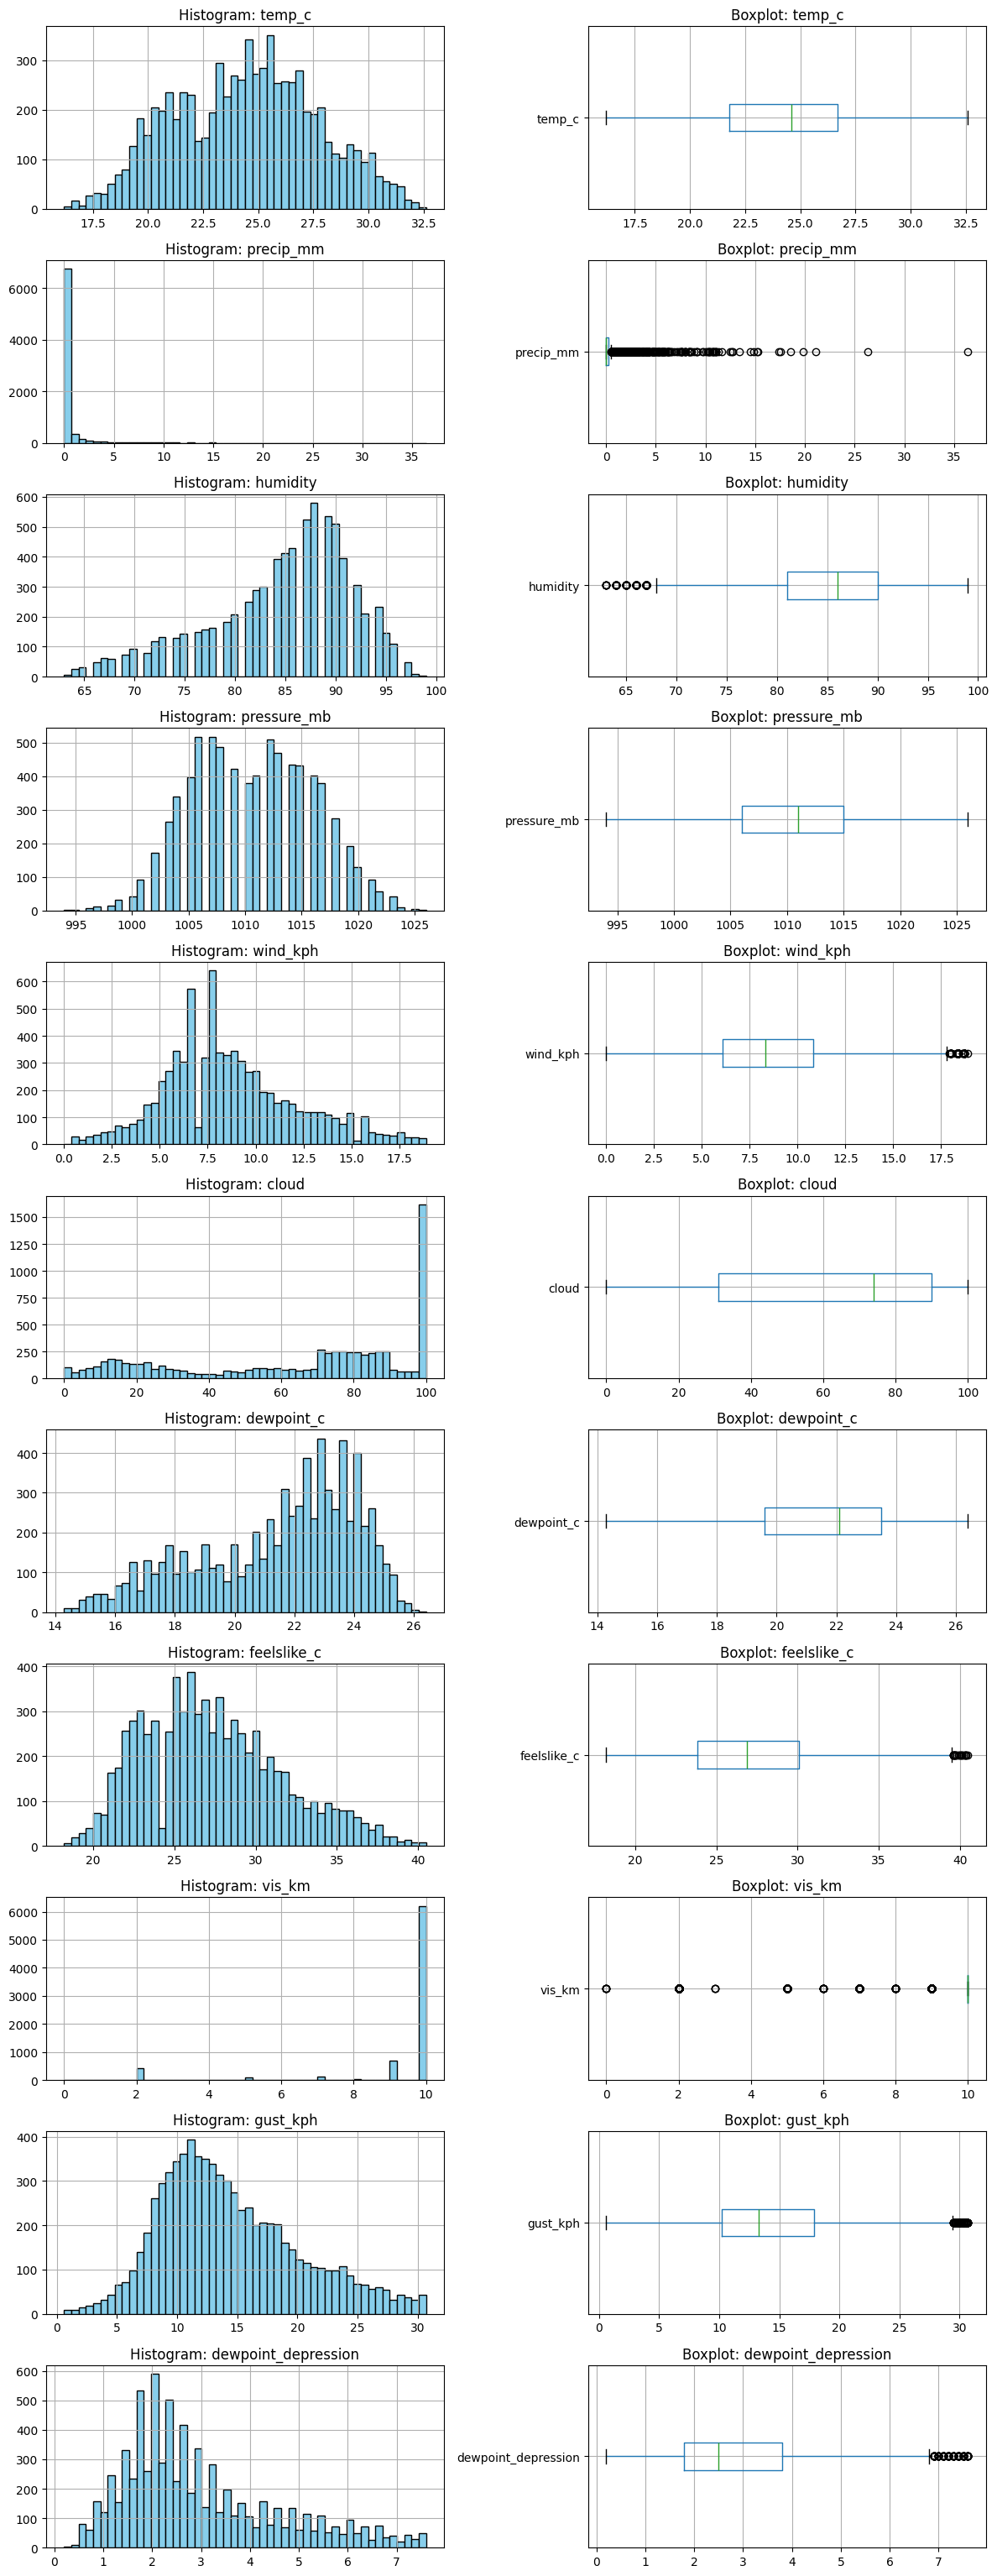

In [8]:
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns

fig, axes = plt.subplots(nrows=len(numerical_columns), ncols=2, figsize=(12, 2.8 * len(numerical_columns)))

if len(numerical_columns) == 1:
    axes = axes.reshape(1, 2)

for i, col in enumerate(numerical_columns):
    df[[col]].hist(bins=50, ax=axes[i, 0], color='skyblue', edgecolor='black')
    axes[i, 0].set_title(f'Histogram: {col}')

    df[[col]].boxplot(ax=axes[i, 1], vert=False)
    axes[i, 1].set_title(f'Boxplot: {col}')

plt.tight_layout()
plt.show()


In [9]:
# Tạo ánh xạ từ nhãn (chuỗi) sang số nguyên
label_mapping = {label: idx for idx, label in enumerate(df['condition'].unique())}

# Mã hóa cột condition trong train và test
df['condition_encoded'] = df['condition'].map(label_mapping)

# Nếu cột 'condition' cũng có trong test_df:
if 'condition' in df.columns:
    df['condition_encoded'] = df['condition'].map(label_mapping)

# In kiểm tra
print("Ánh xạ nhãn -> số:")
for k, v in label_mapping.items():
    print(f"{k}: {v}")


Ánh xạ nhãn -> số:
Patchy rain possible: 0
Cloudy: 1
Partly cloudy: 2
Clear: 3
Moderate or heavy rain shower: 4
Heavy rain at times: 5
Moderate rain at times: 6
Overcast: 7
Sunny: 8
Light rain shower: 9
Light rain: 10
Light drizzle: 11
Patchy light drizzle: 12
Moderate rain: 13
Heavy rain: 14
Patchy light rain with thunder: 15
Mist: 16


## Dữ liệu sau quá trình

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7536 entries, 1 to 8759
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   temp_c               7536 non-null   float64
 1   precip_mm            7536 non-null   float64
 2   humidity             7536 non-null   int64  
 3   pressure_mb          7536 non-null   float64
 4   wind_kph             7536 non-null   float64
 5   cloud                7536 non-null   int64  
 6   dewpoint_c           7536 non-null   float64
 7   feelslike_c          7536 non-null   float64
 8   vis_km               7536 non-null   float64
 9   gust_kph             7536 non-null   float64
 10  condition            7536 non-null   object 
 11  dewpoint_depression  7536 non-null   float64
 12  source               7536 non-null   object 
 13  hour                 7536 non-null   int32  
 14  condition_encoded    7536 non-null   int64  
dtypes: float64(9), int32(1), int64(3), object(2

## Trực quan hóa dữ liệu và trích chọn đặc trưng cho 2 bài toán dự đoán và phân loại

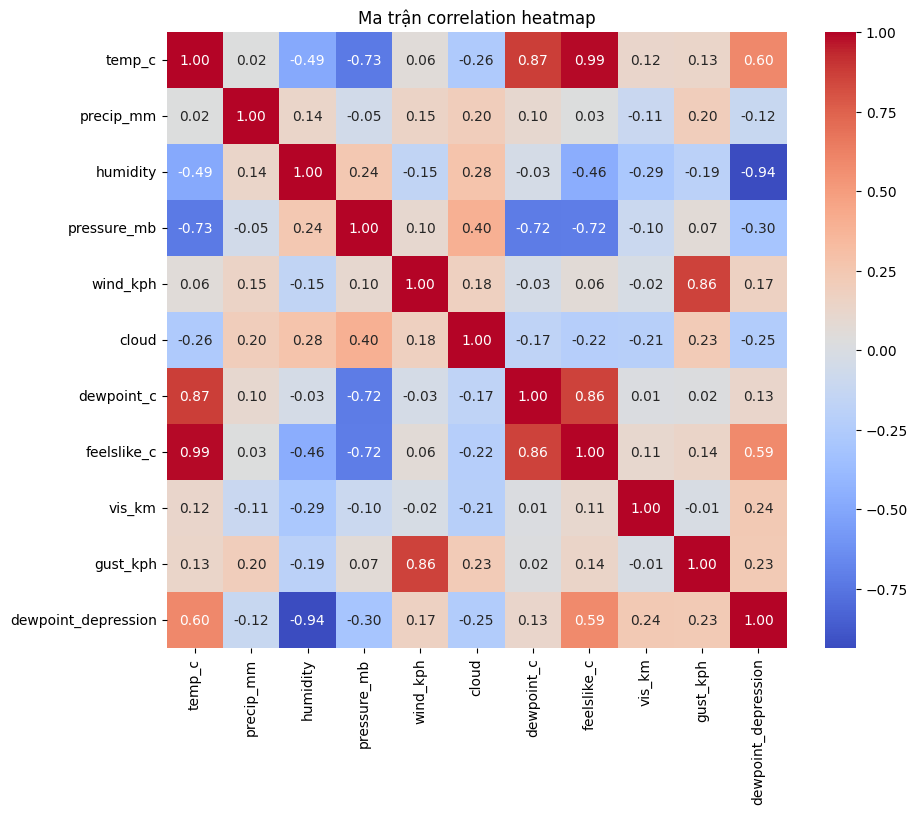

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Giả sử 'condition_encoded' là cột đã qua LabelEncoder
columns_to_exclude = ['condition_encoded']
numeric_data = df.select_dtypes(include=['float64', 'int64']).drop(columns=columns_to_exclude)

# Vẽ heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Ma trận correlation heatmap')
plt.show()


## Đối với bài toán dự đoán nhiệt độ cảm nhận feelslike_c thì các feature có độ tương quan cao với biến mục tiêu được lựa chọn là pressure_mb, dewpoint_depression, humidity, cloud

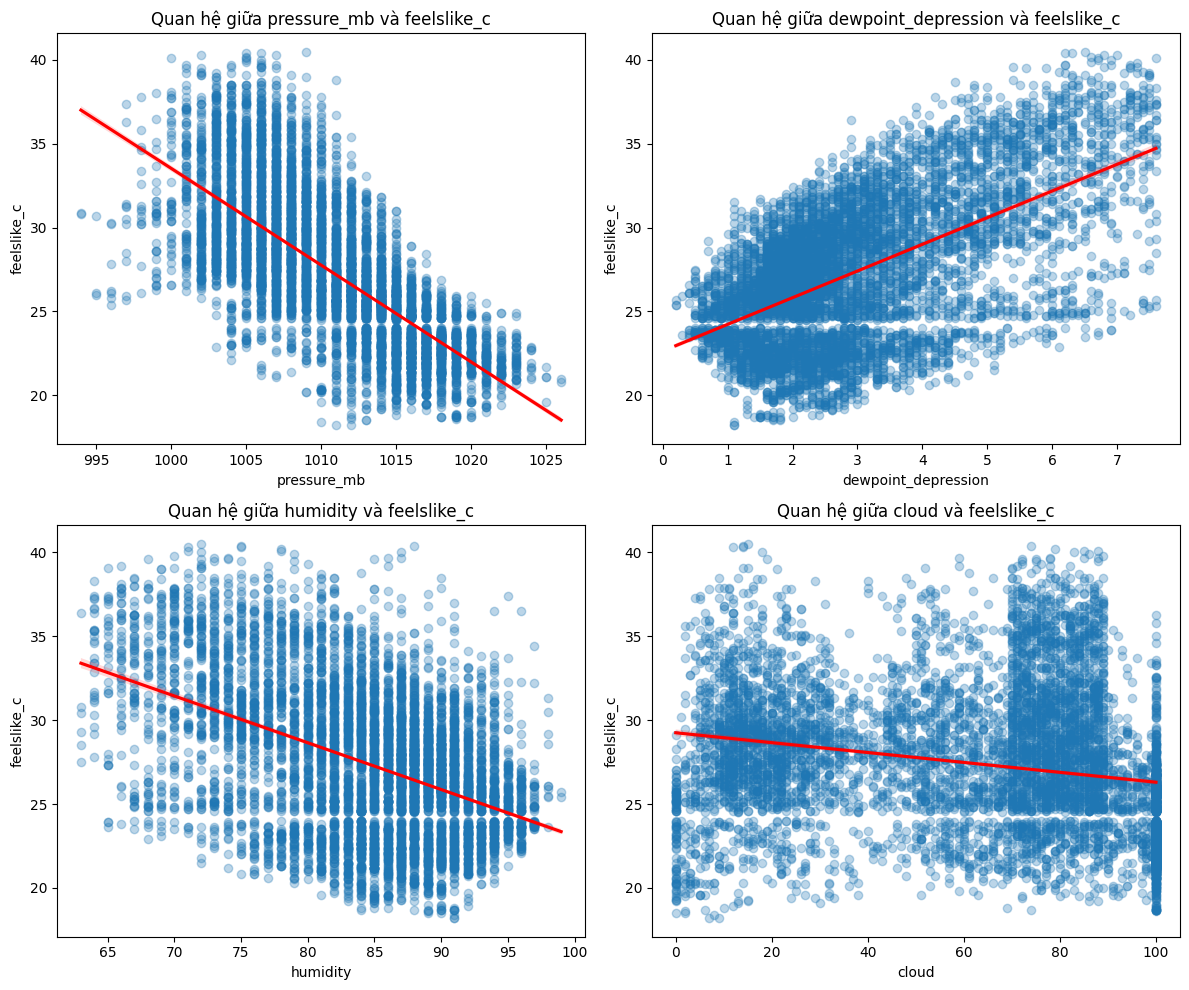

In [19]:
features = ['pressure_mb', 'dewpoint_depression','humidity', 'cloud']
target = 'feelslike_c'

combined_df = df.copy()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()  # Chuyển 2D thành 1D để dễ index

for i, feature in enumerate(features):
    sns.regplot(data=combined_df, x=feature, y=target, ax=axes[i],
                scatter_kws={'alpha':0.3}, line_kws={'color': 'red'})
    axes[i].set_title(f'Quan hệ giữa {feature} và {target}')

plt.tight_layout()
plt.show()



## Đối với bài toán phân loại, lựa chọn mô hình Random Forest để lựa chọn các đặc trưng tốt nhất cho bài toán phân loại

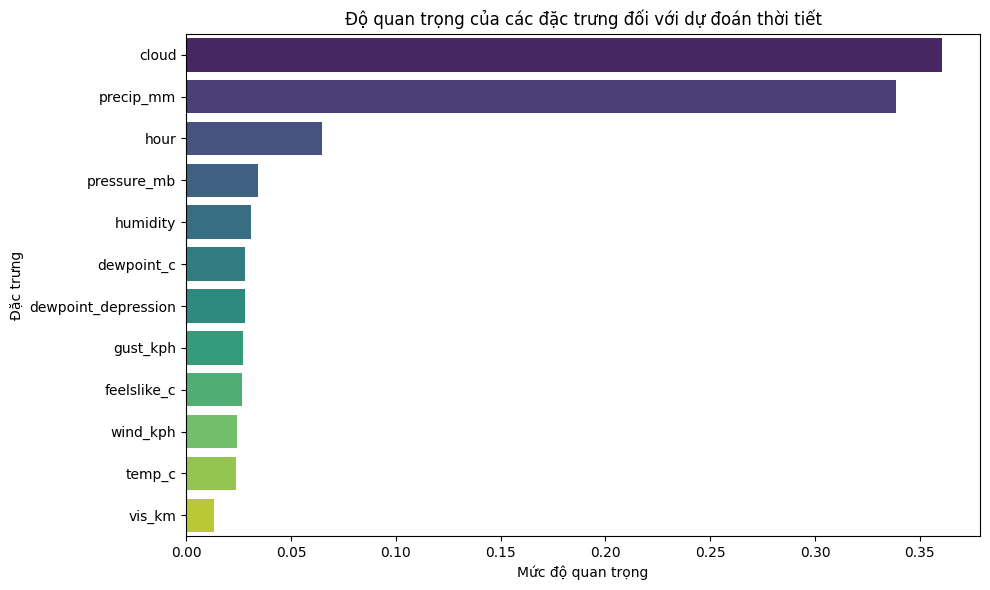

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

df_rf = df.copy()

X = df_rf.drop(columns=['time', 'condition', 'condition_encoded', 'wind_dir', 'source'], errors='ignore')
y = df_rf['condition_encoded']

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X, y)

feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance.values, y=feature_importance.index, hue=feature_importance.index, palette='viridis', dodge=False, legend=False)

plt.title('Độ quan trọng của các đặc trưng đối với dự đoán thời tiết')
plt.xlabel('Mức độ quan trọng')
plt.ylabel('Đặc trưng')
plt.tight_layout()
plt.show()


## Chọn top 7 feature quan trọng nhất là cloud, precip_mm và hour, pressure_md và humidity

In [14]:
selected_features = feature_importance.index.tolist()
selected_top7_features = selected_features[:7]
print("Top 7 đặc trưng quan trọng nhất:", selected_top7_features)

Top 7 đặc trưng quan trọng nhất: ['cloud', 'precip_mm', 'hour', 'pressure_mb', 'humidity', 'dewpoint_c', 'dewpoint_depression']


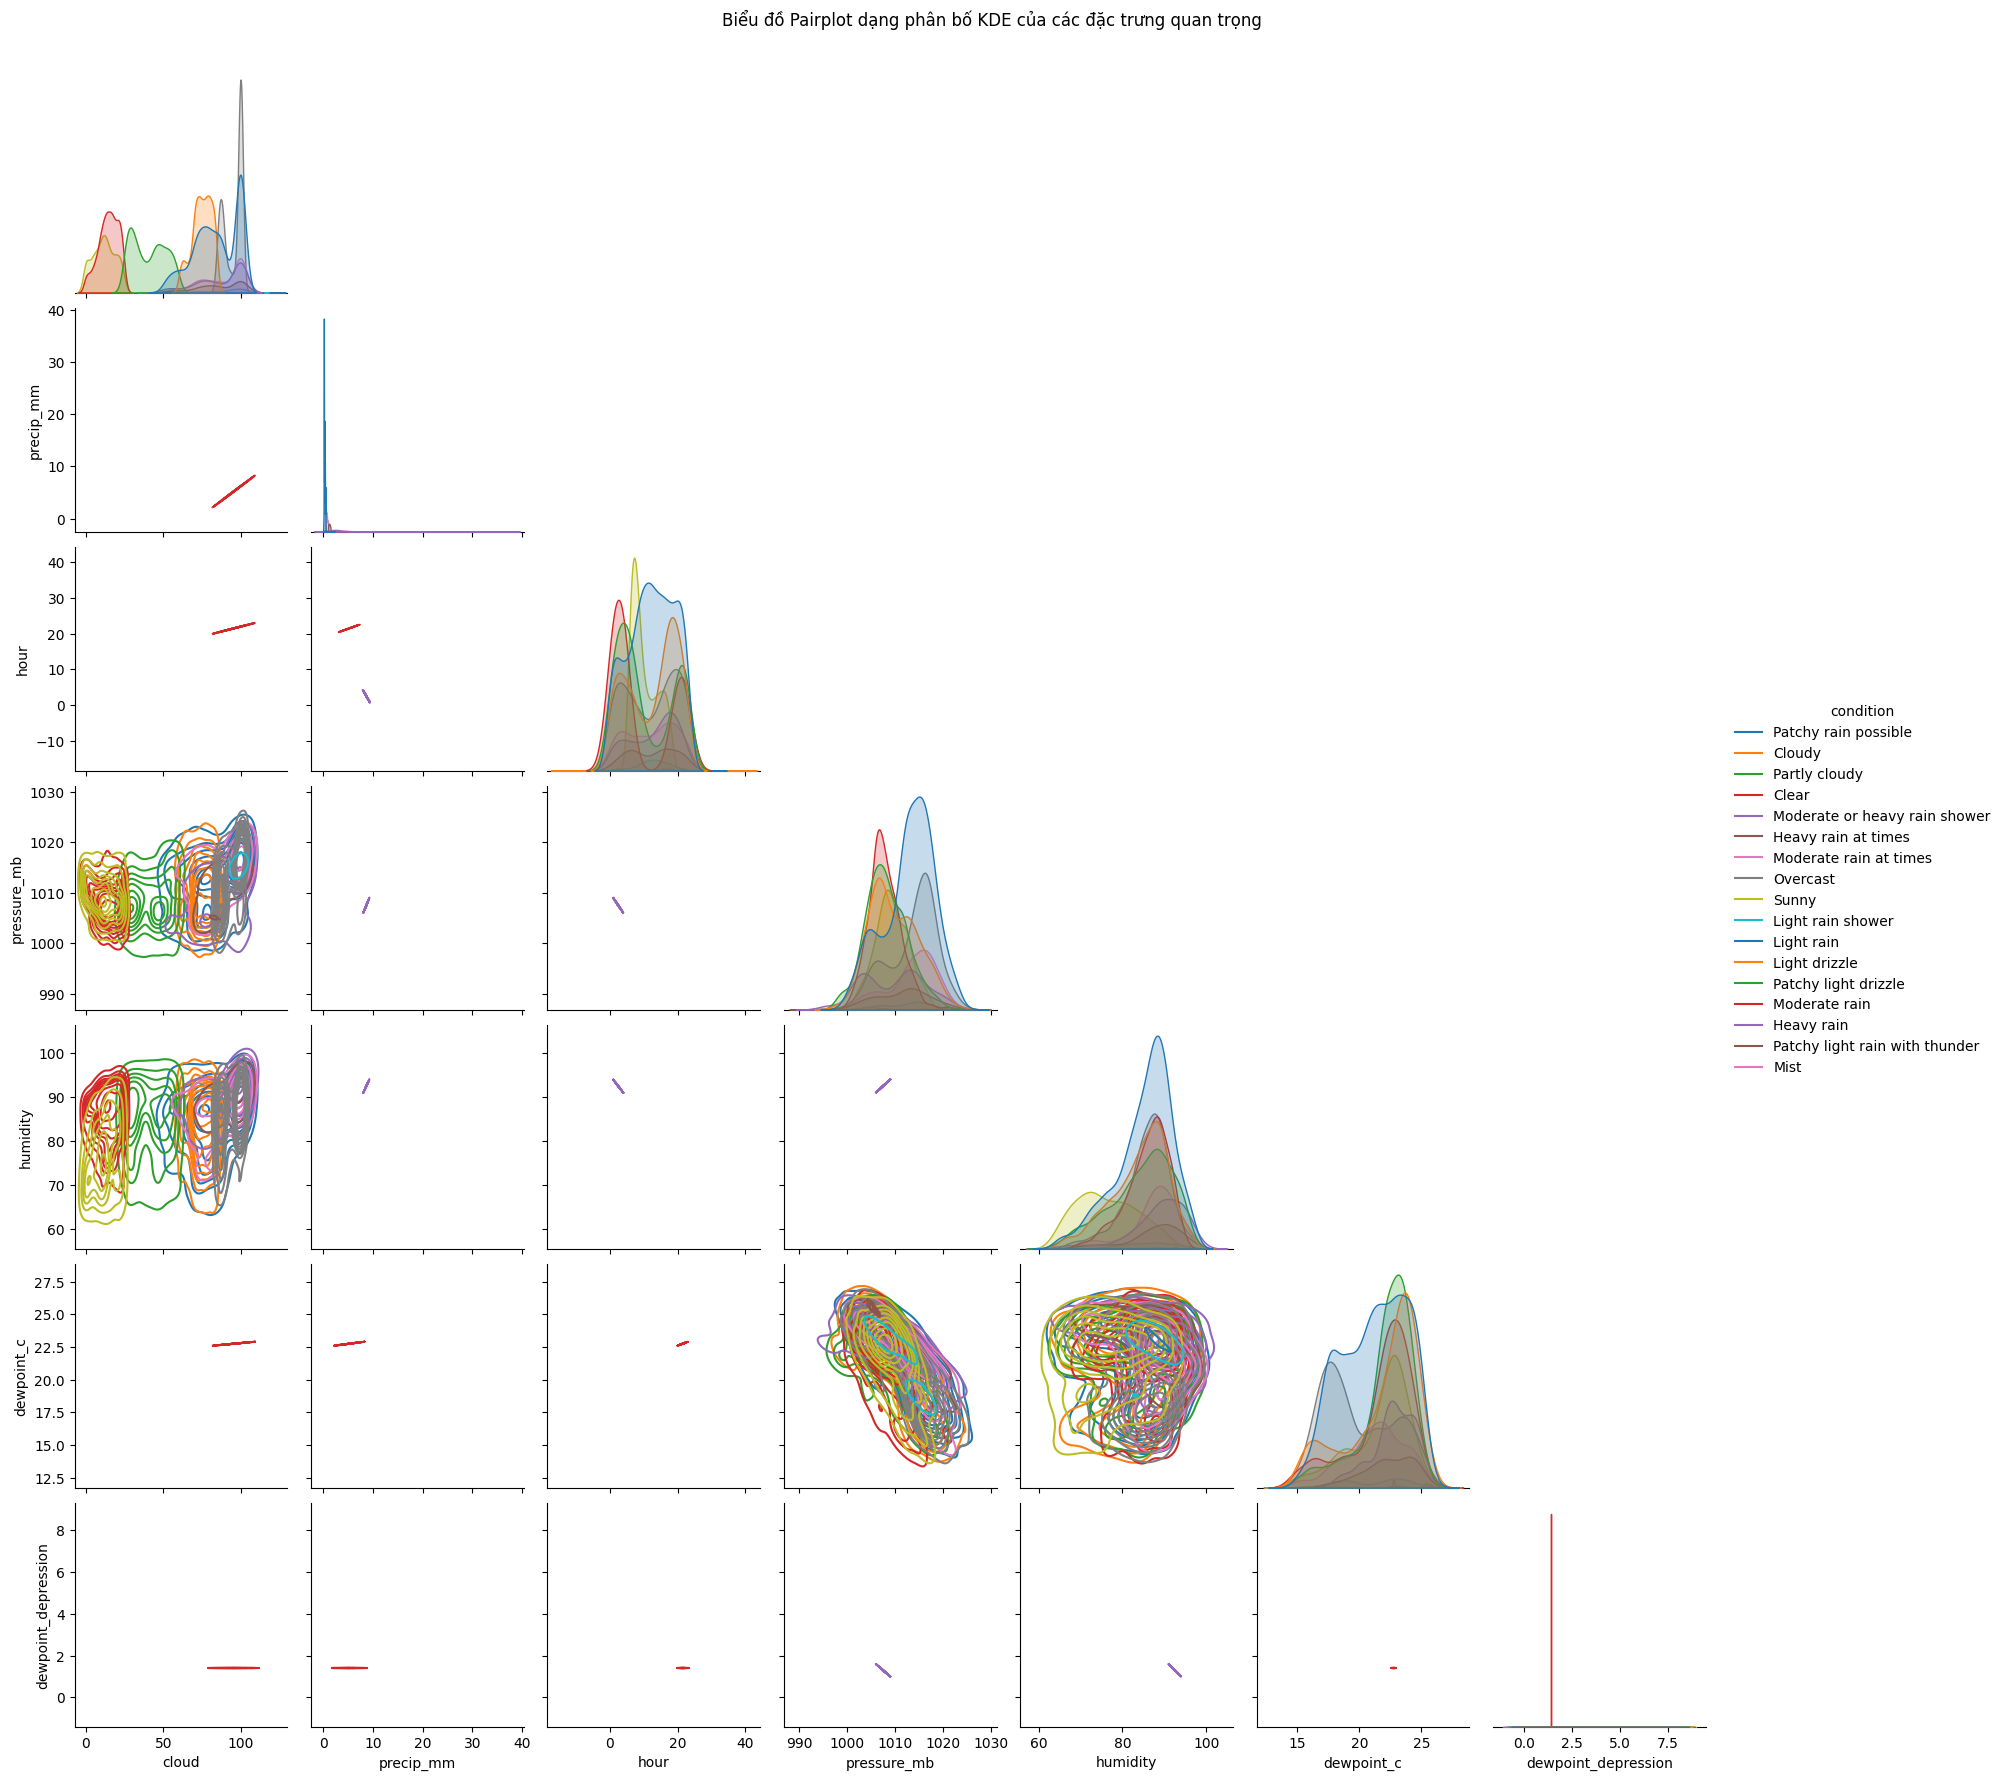

In [15]:
plot_df = df[selected_top7_features + ['condition']]

# Vẽ biểu đồ pairplot kiểu vùng phân bố (density plot)
sns.pairplot(plot_df, hue='condition', kind='kde', corner=True, palette='tab10')
plt.suptitle('Biểu đồ Pairplot dạng phân bố KDE của các đặc trưng quan trọng', y=1.02)
plt.show()

## Chia tập dữ liệu thô thành 2 file train và test

In [16]:
from sklearn.model_selection import train_test_split

train_df_clean, test_df_clean = train_test_split(df, test_size=0.2, random_state=42)

print(f"Kích thước tập train: {train_df_clean.shape[0]} mẫu")
print(f"Kích thước tập test: {test_df_clean.shape[0]} mẫu")

train_df_clean.to_csv('/content/drive/MyDrive/Data_Science/cleaned_data_train.csv', index=False)
test_df_clean.to_csv('/content/drive/MyDrive/Data_Science/cleaned_data_test.csv', index=False)

Kích thước tập train: 6028 mẫu
Kích thước tập test: 1508 mẫu


## In ra phân bố của tập train và test

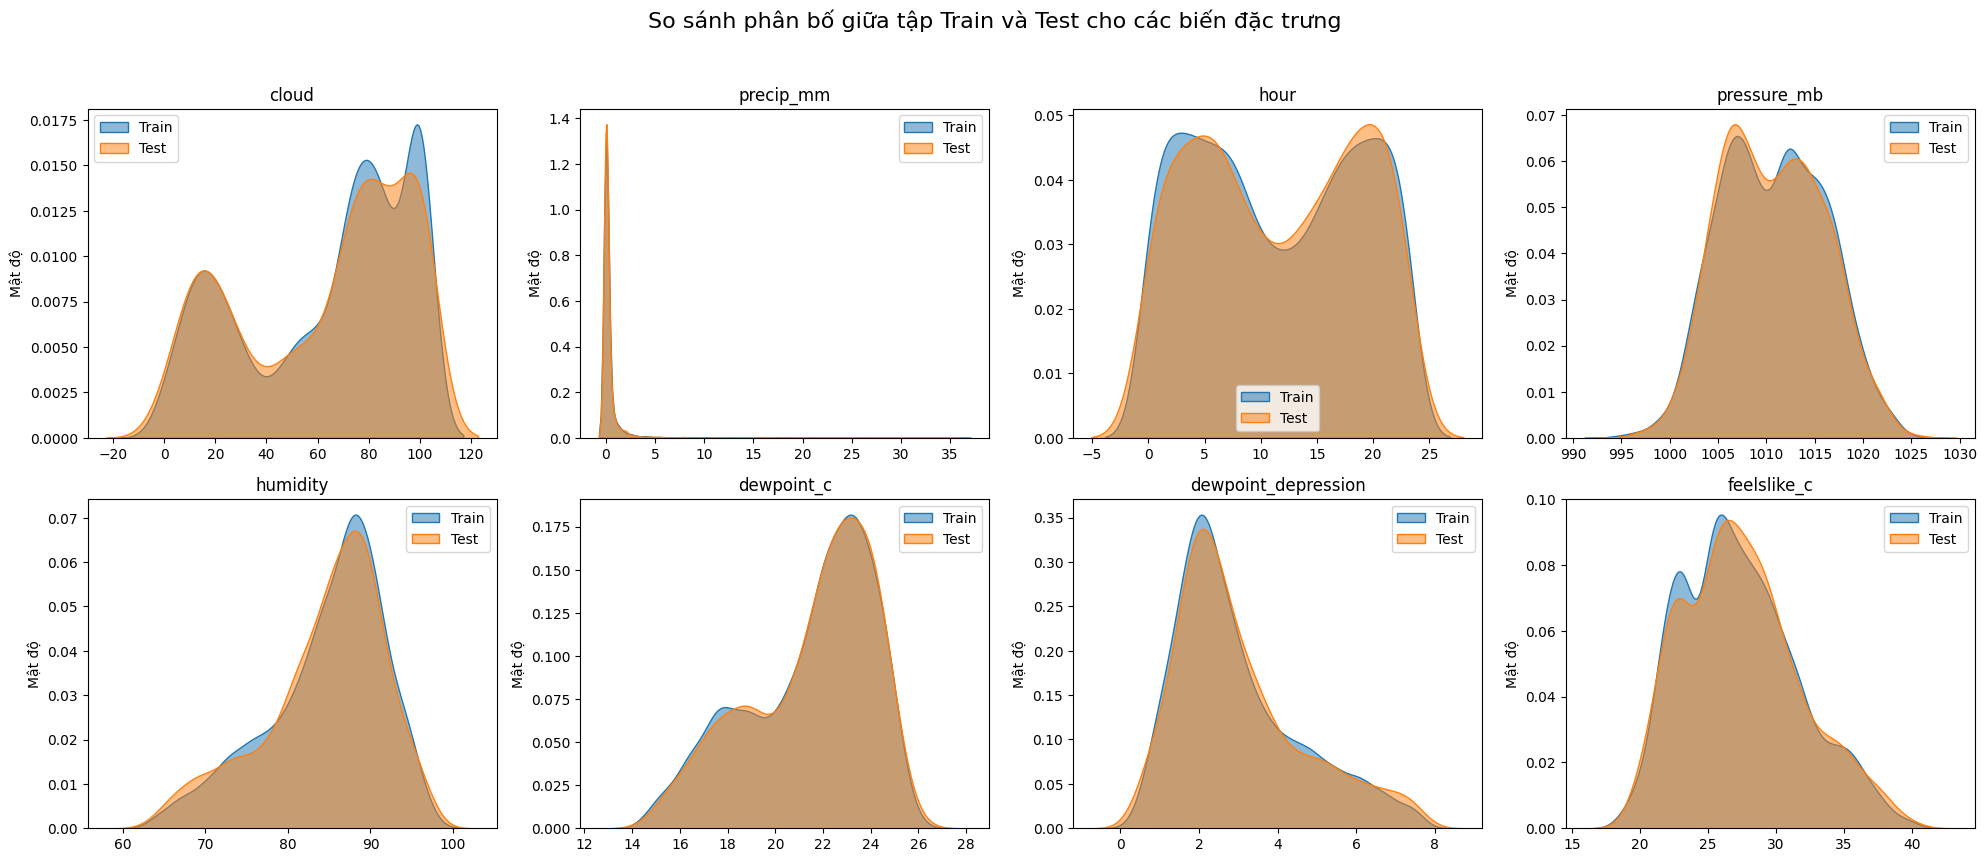

In [17]:
classification_features = ['cloud', 'precip_mm', 'hour', 'pressure_mb', 'humidity']
regression_features = ['cloud', 'precip_mm', 'hour', 'pressure_mb', 'humidity', 'dewpoint_c', 'dewpoint_depression']
aim_features = ['feelslike_c']

# Gộp lại & loại bỏ trùng lặp nếu có
all_features = list(dict.fromkeys(classification_features + regression_features + aim_features))

# Tạo figure 3x4
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(20, 12))
axes = axes.flatten()

# Vẽ từng biểu đồ KDE
for i, col in enumerate(all_features):
    ax = axes[i]
    sns.kdeplot(train_df_clean[col], label='Train', fill=True, common_norm=False, alpha=0.5, ax=ax)
    sns.kdeplot(test_df_clean[col], label='Test', fill=True, common_norm=False, alpha=0.5, ax=ax)
    ax.set_title(f'{col}')
    ax.set_xlabel('')
    ax.set_ylabel('Mật độ')
    ax.legend()

# Tắt các ô còn trống (nếu tổng số biến < 12)
for j in range(len(all_features), len(axes)):
    fig.delaxes(axes[j])

# Tiêu đề tổng và căn lề
fig.suptitle('So sánh phân bố giữa tập Train và Test cho các biến đặc trưng', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

